**STEP 1: Import & Load Dataset**

In [6]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**STEP 2: EDA (Exploratory Data Analysis)**

<Axes: xlabel='sentiment'>

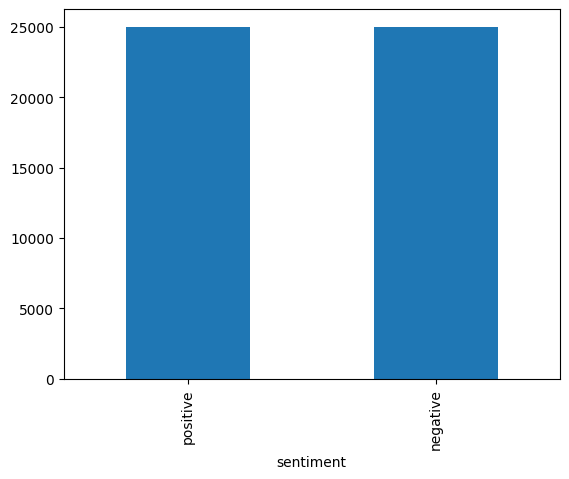

In [7]:
df["sentiment"].value_counts().plot(kind="bar")

**STEP 3: Text Cleaning**

In [8]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text

df["cleaned_text"] = df["review"].apply(clean_text)


**STEP 4: TF-IDF (CORE NLP STEP)**

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df["cleaned_text"])

y = df["sentiment"]

**STEP 5: Model Training**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

**STEP 6: Evaluation**

In [11]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8679


## Final Conclusion

- TF-IDF improved performance compared to raw text
- Naive Bayes performed well for sentiment classification
- Model achieved ~86% accuracy
